# Dimensionality Reduction & Clustering Sensitivity Analysis

Addresses reviewer comment: *"Have the authors evaluated alternative dimensionality reduction methods or clustering methods?"*

## Part 1: Dimensionality Reduction Sensitivity
Compare PCA vs no-PCA (scale only) as input to Harmony, keeping clustering fixed (Leiden).

## Part 2: Clustering Method Sensitivity
Compare Leiden, Louvain, K-Means, Hierarchical (Ward), and Spectral clustering on the
same Harmony-corrected embedding.

## Evaluation
Pairwise ARI and NMI across all methods, plus a 2-column composite figure
(UMAP / spatial) following the layout used in
`Random_Clustering_reproducibility.ipynb`.

In [3]:
import anndata as ad
import os
import numpy as np
import scanpy as sc
import squidpy as sq
import harmonypy as hm
import umap
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, silhouette_score
from sklearn.cluster import KMeans, AgglomerativeClustering, SpectralClustering
from sklearn.neighbors import KNeighborsClassifier
from matplotlib.lines import Line2D

## 1. Load and preprocess data

In [ ]:
# Load nuclear protein intensity matrices of the two brain sections.
# Brain 1 (~178927 cells, 18 markers) and Brain 2 (~194890 cells, 15 markers)
# are pre-saved h5ad snapshots produced by the upstream segmentation pipeline.
adata_1st_brain = ad.read_h5ad('input/adata_18_nuclear_46_prot_brain1.h5ad')
adata_2nd_brain = ad.read_h5ad('input/brain2_nuclear_int_18prot.h5ad')

# Prefix obs_names so we can disambiguate same-numbered cells across brains
# AFTER concat (this prevents the row-order alignment bugs we hit earlier).
adata_1st_brain.obs_names = 'b1_' + adata_1st_brain.obs_names.astype(str).str.strip()
adata_2nd_brain.obs_names = 'b2_' + adata_2nd_brain.obs_names.astype(str).str.strip()

common_vars = adata_1st_brain.var_names.intersection(adata_2nd_brain.var_names)
adata_1 = adata_1st_brain[:, common_vars].copy()
adata_2 = adata_2nd_brain[:, common_vars].copy()

In [9]:
# Combine
adata_both = ad.concat(
    [adata_1, adata_2], join="outer", label="dataset",
    keys=["1st_brain", "2nd_brain"],
)
adata_both.obs_names_make_unique()   # belt-and-suspenders -- prefixes should already disambiguate

adata_both.layers["counts"] = adata_both.X.copy()
sc.pp.normalize_total(adata_both, inplace=True)
sc.pp.log1p(adata_both)

print(adata_both)
print(f"Features: {adata_both.var_names.tolist()}")
print(f"obs_names unique: {adata_both.obs_names.is_unique}")

AnnData object with n_obs × n_vars = 373817 × 15
    obs: 'batch', 'z_layer', 'cluster', 'leiden', 'dataset'
    uns: 'log1p'
    obsm: 'spatial', 'spatial3d', 'X_pca', 'X_umap'
    layers: 'counts'
Features: ['CBP', 'CDK9', 'DAPI', 'H2K119u1', 'H3K27ac', 'H3K4me1', 'H3K4me3', 'H4K16ac', 'H4K8ac', 'HP1a', 'MECP2', 'Matrin3', 'PolII S5p', 'SF3a66', 'mH2A1']
obs_names unique: True


---
# Part 1: Dimensionality Reduction Sensitivity
## Pipeline A: PCA -> Harmony (original pipeline)

In [11]:
# Pipeline A: PCA -> Harmony
adata_pca = adata_both.copy()
sc.tl.pca(adata_pca, svd_solver="arpack")

# takes ~ 30 mins for our dataset
ho_pca = hm.run_harmony(
    adata_pca.obsm['X_pca'], adata_pca.obs, 'dataset',
    theta=6, lamb=0.3, sigma=0.02, nclust=100,
    max_iter_harmony=20, random_state=42,
)
adata_pca.obsm['X_harmony'] = ho_pca.Z_corr.T
print(f"Pipeline A (PCA): Harmony embedding shape = {adata_pca.obsm['X_harmony'].shape}")

2026-05-12 10:09:02,869 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2026-05-12 10:09:34,442 - harmonypy - INFO - sklearn.KMeans initialization complete.
2026-05-12 10:09:36,075 - harmonypy - INFO - Iteration 1 of 20
2026-05-12 10:11:56,067 - harmonypy - INFO - Iteration 2 of 20
2026-05-12 10:14:15,962 - harmonypy - INFO - Iteration 3 of 20
2026-05-12 10:16:37,200 - harmonypy - INFO - Iteration 4 of 20
2026-05-12 10:18:59,622 - harmonypy - INFO - Iteration 5 of 20
2026-05-12 10:21:19,757 - harmonypy - INFO - Iteration 6 of 20
2026-05-12 10:23:41,288 - harmonypy - INFO - Iteration 7 of 20
2026-05-12 10:26:01,693 - harmonypy - INFO - Iteration 8 of 20
2026-05-12 10:28:21,863 - harmonypy - INFO - Iteration 9 of 20
2026-05-12 10:30:42,170 - harmonypy - INFO - Iteration 10 of 20
2026-05-12 10:33:02,609 - harmonypy - INFO - Iteration 11 of 20
2026-05-12 10:35:23,403 - harmonypy - INFO - Converged after 11 iterations


Pipeline A (PCA): Harmony embedding shape = (373817, 14)


In [55]:
vr = adata_pca.uns['pca']['variance_ratio']
print(len(vr))                  # number of components actually returned
print(vr.sum())                 # cumulative fraction of variance retained
print(np.cumsum(vr))            # per-component cumulative curve

14
0.9998927807915765
[0.58537517 0.7879575  0.84951786 0.89696848 0.92371734 0.94681431
 0.96308138 0.97410445 0.98224907 0.98824631 0.9922024  0.99583769
 0.99828293 0.99989278]


In [12]:
# Pipeline A: UMAP, neighbors, Leiden
X_pca_1 = adata_pca[adata_pca.obs['dataset'] == '1st_brain'].obsm['X_harmony']
X_pca_2 = adata_pca[adata_pca.obs['dataset'] == '2nd_brain'].obsm['X_harmony']

reducer_a = umap.UMAP(n_neighbors=5, min_dist=0.1, n_components=2, random_state=42)
reducer_a.fit(X_pca_2)
X_umap_a = np.vstack([reducer_a.transform(X_pca_1), reducer_a.transform(X_pca_2)])
adata_pca.obsm['X_umap'] = X_umap_a

sc.pp.neighbors(adata_pca, n_neighbors=10, random_state=42, use_rep='X_harmony')
sc.tl.leiden(adata_pca, resolution=0.8, random_state=38)

print(f"Pipeline A clusters: {adata_pca.obs['leiden'].nunique()}")

C:\Users\liany\AppData\Local\anaconda3\Lib\site-packages\umap\umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")
C:\Users\liany\AppData\Local\Temp\ipykernel_30184\2328249439.py:11: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata_pca, resolution=0.8, random_state=38)


Pipeline A clusters: 34


In [1]:
sc.set_figure_params(figsize=(8, 8))
sc.pl.umap(adata_pca, color=["dataset"], size=5, alpha=0.9)

NameError: name 'sc' is not defined

In [14]:
# Save / reload (commented; uncomment to skip the heavy Harmony rerun)
adata_pca.write('output/adata_plot_harmony_pca_2_brains.h5ad')
# adata_pca = ad.read('output/adata_plot_harmony_pca_2_brains.h5ad')

## Pipeline B: Scale (no PCA) -> Harmony

In [34]:
# Pipeline B: Scale -> Harmony (no PCA)
adata_nopca = adata_both.copy()
adata_nopca.layers["log1p"] = adata_nopca.X.copy()
sc.pp.scale(adata_nopca)

ho_nopca = hm.run_harmony(
    adata_nopca.X, adata_nopca.obs, 'dataset',
    theta=6, lamb=0.3, sigma=0.02, nclust=100,
    max_iter_harmony=20, random_state=42,
)
adata_nopca.obsm['X_harmony'] = ho_nopca.Z_corr.T
print(f"Pipeline B (no PCA): Harmony embedding shape = {adata_nopca.obsm['X_harmony'].shape}")

2026-05-12 10:56:41,866 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2026-05-12 10:57:04,433 - harmonypy - INFO - sklearn.KMeans initialization complete.
2026-05-12 10:57:06,308 - harmonypy - INFO - Iteration 1 of 20
2026-05-12 10:59:26,879 - harmonypy - INFO - Iteration 2 of 20
2026-05-12 11:01:46,230 - harmonypy - INFO - Iteration 3 of 20
2026-05-12 11:04:05,868 - harmonypy - INFO - Iteration 4 of 20
2026-05-12 11:06:24,980 - harmonypy - INFO - Iteration 5 of 20
2026-05-12 11:08:44,557 - harmonypy - INFO - Iteration 6 of 20
2026-05-12 11:11:04,861 - harmonypy - INFO - Iteration 7 of 20
2026-05-12 11:13:12,714 - harmonypy - INFO - Iteration 8 of 20
2026-05-12 11:15:34,155 - harmonypy - INFO - Iteration 9 of 20
2026-05-12 11:17:34,248 - harmonypy - INFO - Converged after 9 iterations


Pipeline B (no PCA): Harmony embedding shape = (373817, 15)


In [35]:
# Pipeline B: UMAP, neighbors, Leiden
X_nopca_1 = adata_nopca[adata_nopca.obs['dataset'] == '1st_brain'].obsm['X_harmony']
X_nopca_2 = adata_nopca[adata_nopca.obs['dataset'] == '2nd_brain'].obsm['X_harmony']

reducer_b = umap.UMAP(n_neighbors=5, min_dist=0.1, n_components=2, random_state=42)
reducer_b.fit(X_nopca_2)
X_umap_b = np.vstack([reducer_b.transform(X_nopca_1), reducer_b.transform(X_nopca_2)])
adata_nopca.obsm['X_umap'] = X_umap_b

sc.pp.neighbors(adata_nopca, n_neighbors=10, random_state=42, use_rep='X_harmony')
sc.tl.leiden(adata_nopca, resolution=0.8, random_state=38)

print(f"Pipeline B clusters: {adata_nopca.obs['leiden'].nunique()}")

C:\Users\liany\AppData\Local\anaconda3\Lib\site-packages\umap\umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


Pipeline B clusters: 31


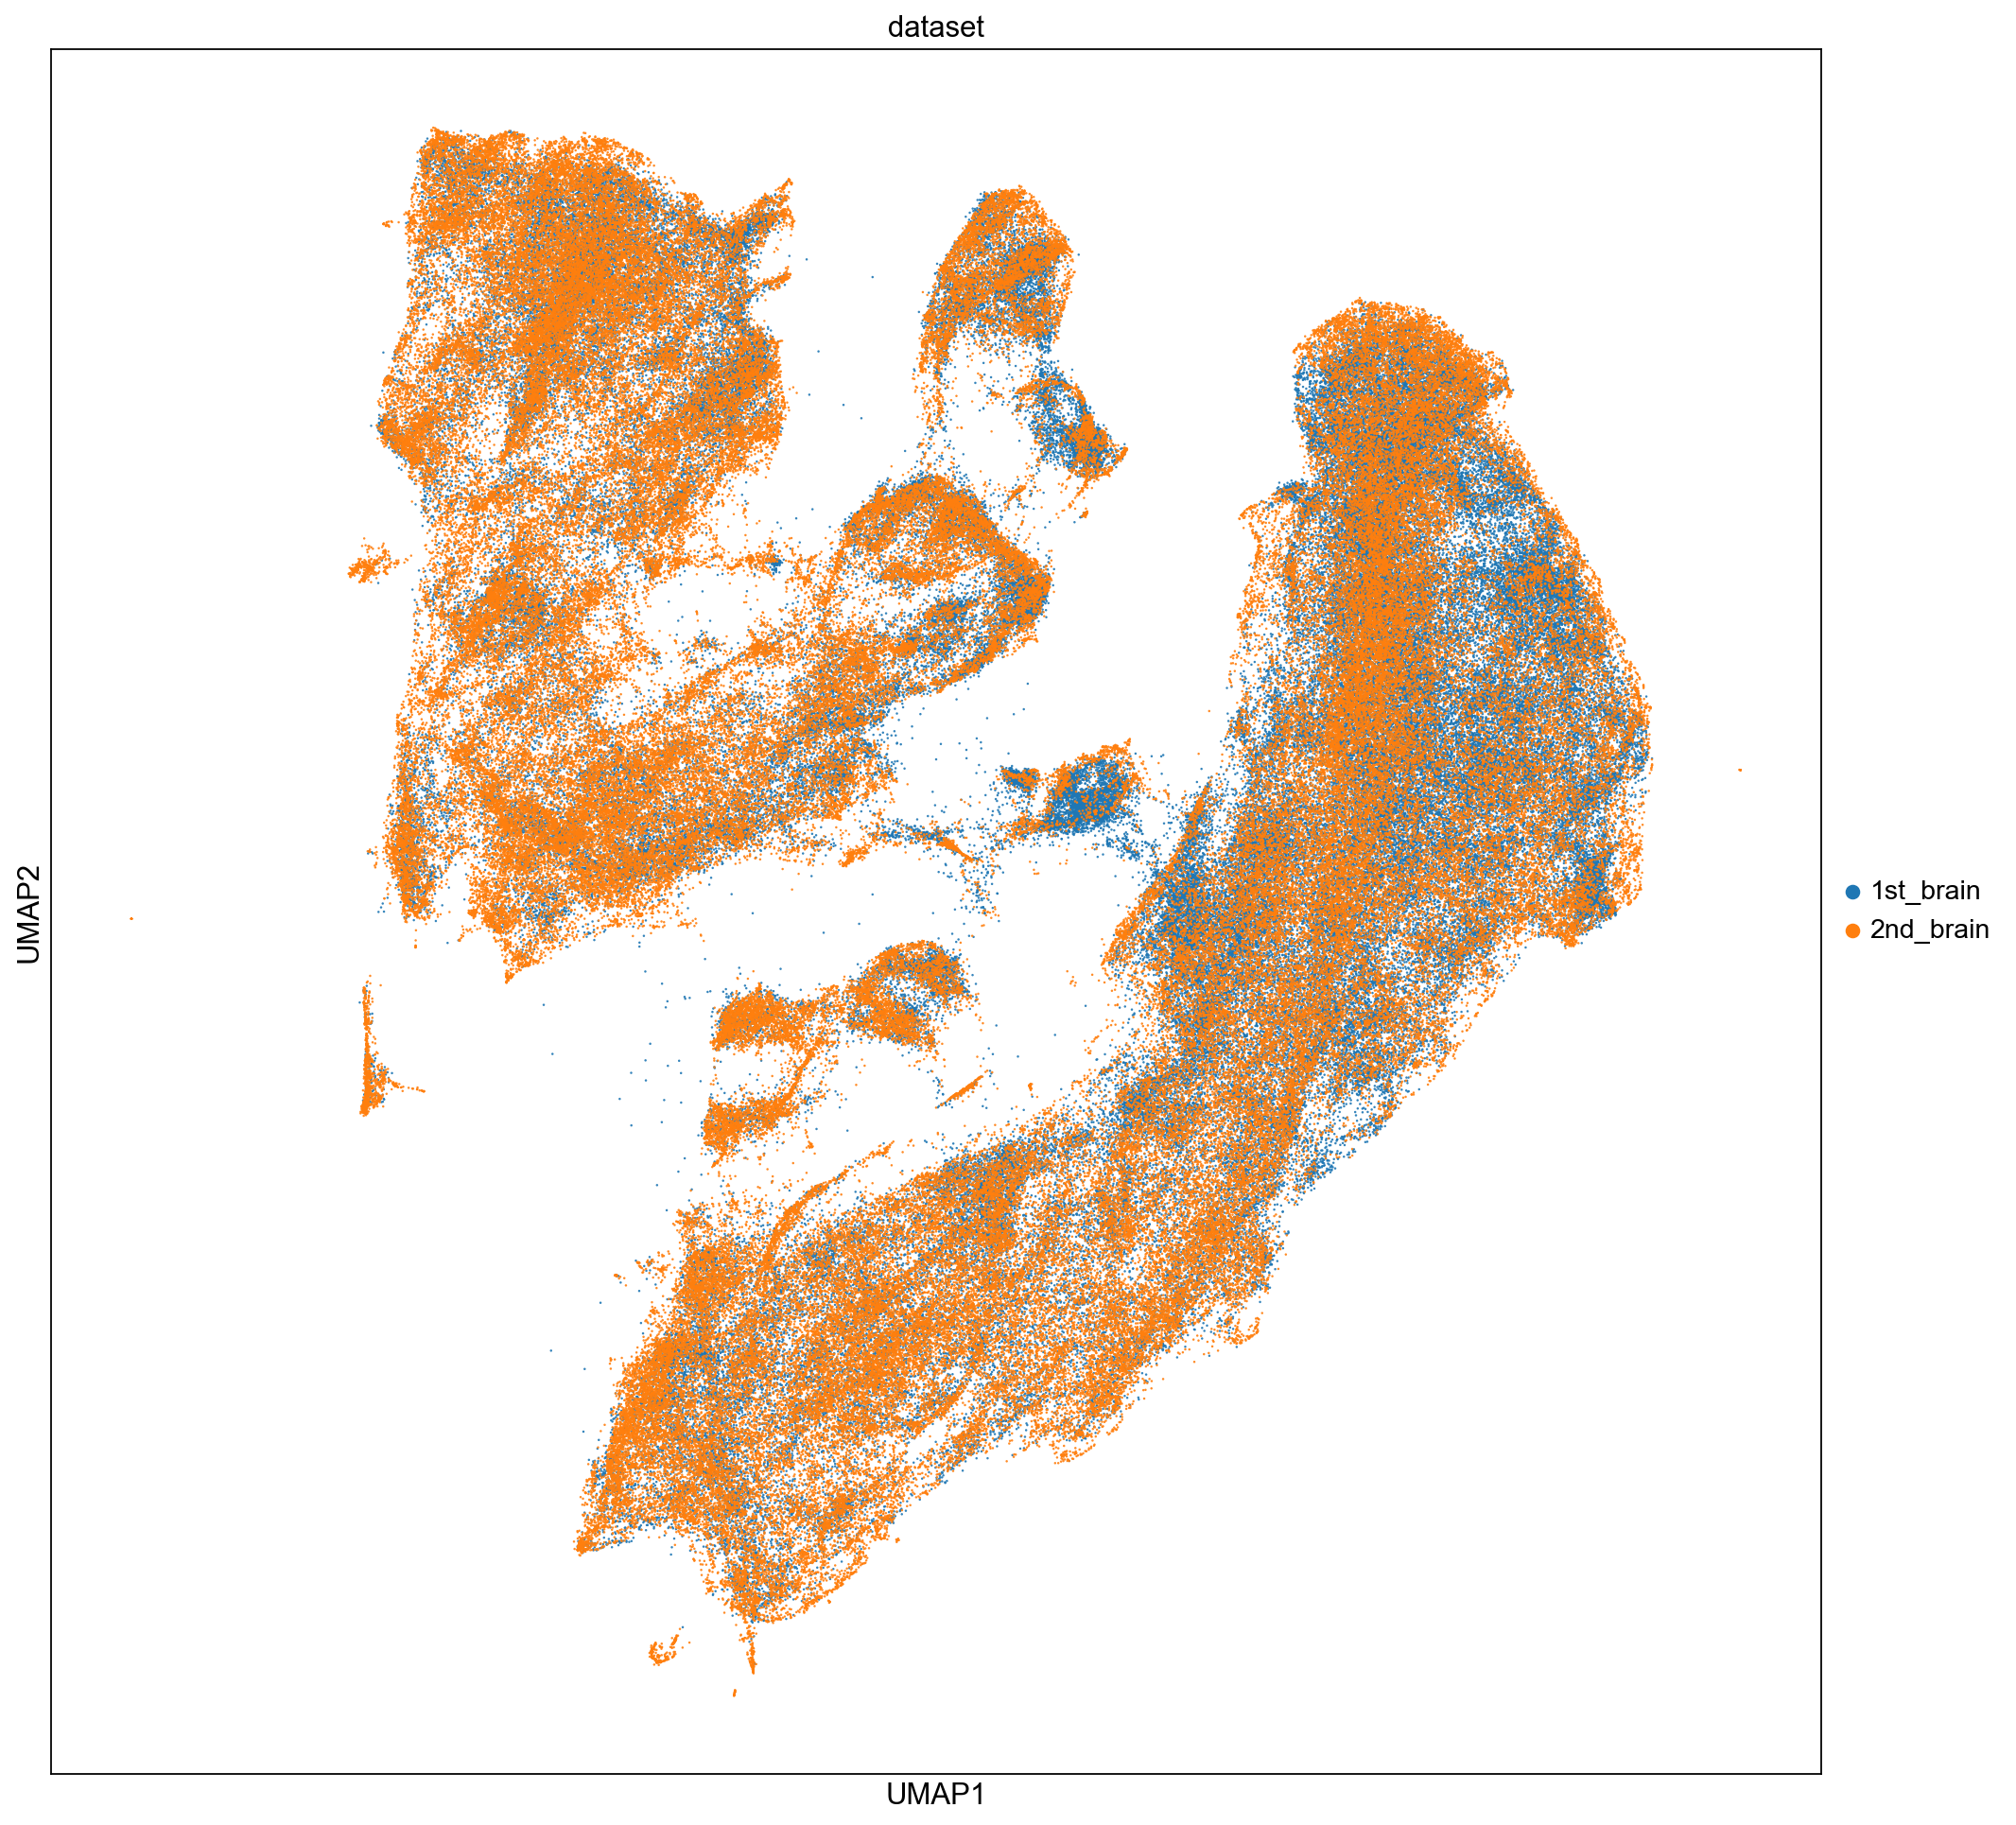

In [36]:
sc.set_figure_params(figsize=(15, 15))
sc.pl.umap(adata_nopca, color=["dataset"], size=5, alpha=0.9)

In [37]:
# Save / reload
adata_nopca.write('output/adata_plot_harmony_no_pca_2_brains.h5ad')
# adata_nopca = ad.read('output/adata_plot_harmony_no_pca_2_brains.h5ad')

---
# Part 2: Clustering Method Sensitivity

Apply Louvain, K-Means, Hierarchical (Ward), and Spectral on the PCA -> Harmony
embedding from Pipeline A. Cluster count is matched to Leiden's k.

In [16]:
# Determine k from Leiden so K-Means / Hierarchical / Spectral get the same target.
n_leiden = adata_pca.obs['leiden'].nunique()
print(f"Number of Leiden clusters: {n_leiden} (used as k for K-Means / Hierarchical / Spectral)")

Number of Leiden clusters: 34 (used as k for K-Means / Hierarchical / Spectral)


In [121]:
# Louvain on the PCA Harmony graph (uses neighbors already in adata_pca).
sc.tl.louvain(adata_pca, resolution=1.1, random_state=38)
print(f"Louvain clusters: {adata_pca.obs['louvain'].nunique()}")

Louvain clusters: 34


In [18]:
# K-Means on the PCA Harmony embedding.
X_harmony_pca = adata_pca.obsm['X_harmony']

kmeans = KMeans(n_clusters=n_leiden, random_state=42, n_init=10)
adata_pca.obs['kmeans'] = kmeans.fit_predict(X_harmony_pca).astype(str)
print(f"K-Means clusters: {adata_pca.obs['kmeans'].nunique()}")

K-Means clusters: 34


In [19]:
# Hierarchical (Ward) -- subsample then assign remaining cells via KNN.
max_hier = 50000

print(f"Subsampling {max_hier} cells for Hierarchical clustering (full data: {adata_pca.n_obs})")
np.random.seed(42)
sub_idx = np.random.choice(adata_pca.n_obs, max_hier, replace=False)
X_sub = X_harmony_pca[sub_idx]

ward = AgglomerativeClustering(n_clusters=n_leiden, linkage='ward')
sub_labels = ward.fit_predict(X_sub)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_sub, sub_labels)
adata_pca.obs['hierarchical'] = knn.predict(X_harmony_pca).astype(str)
print(f"Hierarchical clusters: {adata_pca.obs['hierarchical'].nunique()}")

Subsampling 50000 cells for Hierarchical clustering (full data: 373817)
Hierarchical clusters: 34


In [20]:
# Spectral clustering -- subsample if too large, then assign remaining cells.
n_cells = adata_pca.n_obs
max_spectral = 50000

if n_cells > max_spectral:
    print(f"Subsampling {max_spectral} cells for Spectral clustering (full data: {n_cells})")
    np.random.seed(42)
    sub_idx = np.random.choice(n_cells, max_spectral, replace=False)
    X_sub = X_harmony_pca[sub_idx]

    spectral = SpectralClustering(n_clusters=n_leiden, random_state=42,
                                   affinity='nearest_neighbors', n_neighbors=10)
    sub_labels = spectral.fit_predict(X_sub)

    knn = KNeighborsClassifier(n_neighbors=5)
    knn.fit(X_sub, sub_labels)
    adata_pca.obs['spectral'] = knn.predict(X_harmony_pca).astype(str)
else:
    spectral = SpectralClustering(n_clusters=n_leiden, random_state=42,
                                   affinity='nearest_neighbors', n_neighbors=10)
    adata_pca.obs['spectral'] = spectral.fit_predict(X_harmony_pca).astype(str)

print(f"Spectral clusters: {adata_pca.obs['spectral'].nunique()}")

Subsampling 50000 cells for Spectral clustering (full data: 373817)
Spectral clusters: 34


---
# Part 3: Pairwise ARI and NMI across all methods

We align `adata_pca` (PCA pipeline + all extra methods) and `adata_nopca`
(no-PCA Leiden) by `obs_names` rather than positional indexing.  Both AnnData
objects were built from the same `adata_both` so they share the same cell
identities, but a row-order divergence at any earlier step (re-read from
disk, etc.) would silently break a positional comparison -- aligning by
obs_names is bug-proof.

In [141]:
# Pairwise sensitivity: PCA-pipeline methods only (leiden_noPCA is treated
# separately as the dimensionality-reduction comparison further down).
# Both adata_pca and adata_nopca were built from the same adata_both, so
# obs_names align; we still align by name for safety.
common = adata_pca.obs_names.intersection(adata_nopca.obs_names)
print(f"Cells common to both pipelines: {len(common)} / {adata_pca.n_obs}")

# Reindex each label column to the common cell order. Reindex returns NaN if
# a cell is missing; we drop those rows from the comparison.
def _aligned(adata, key):
    s = pd.Series(adata.obs[key].astype(str).values,
                  index=adata.obs_names.astype(str))
    return s.reindex(common.astype(str))

labels = {
    'leiden':       _aligned(adata_pca, 'leiden'),
    'louvain':      _aligned(adata_pca, 'louvain'),
    'kmeans':       _aligned(adata_pca, 'kmeans'),
    'hierarchical': _aligned(adata_pca, 'hierarchical'),
    'spectral':     _aligned(adata_pca, 'spectral'),
}
labels_df = pd.DataFrame(labels)
valid_mask = labels_df.notna().all(axis=1).values
print(f"Cells with valid labels for every method: {valid_mask.sum()} / {len(labels_df)}")

label_vecs = {k: labels_df[k].values[valid_mask] for k in labels_df.columns}

Cells common to both pipelines: 373817 / 373817
Cells with valid labels for every method: 373817 / 373817


In [143]:
# Pairwise ARI / NMI across all clusterings.
method_names = list(label_vecs.keys())
n = len(method_names)

ari_matrix = np.ones((n, n))
nmi_matrix = np.ones((n, n))

for i in range(n):
    for j in range(i + 1, n):
        a = label_vecs[method_names[i]]
        b = label_vecs[method_names[j]]
        ari = adjusted_rand_score(a, b)
        nmi = normalized_mutual_info_score(a, b)
        ari_matrix[i, j] = ari_matrix[j, i] = ari
        nmi_matrix[i, j] = nmi_matrix[j, i] = nmi

ari_df = pd.DataFrame(ari_matrix, index=method_names, columns=method_names)
nmi_df = pd.DataFrame(nmi_matrix, index=method_names, columns=method_names)

print("Pairwise ARI:")
print(ari_df.round(3))
print("\nPairwise NMI:")
print(nmi_df.round(3))

Pairwise ARI:
              leiden  louvain  kmeans  hierarchical  spectral
leiden         1.000    0.525   0.412         0.386     0.521
louvain        0.525    1.000   0.361         0.341     0.419
kmeans         0.412    0.361   1.000         0.428     0.385
hierarchical   0.386    0.341   0.428         1.000     0.383
spectral       0.521    0.419   0.385         0.383     1.000

Pairwise NMI:
              leiden  louvain  kmeans  hierarchical  spectral
leiden         1.000    0.738   0.675         0.669     0.734
louvain        0.738    1.000   0.645         0.643     0.691
kmeans         0.675    0.645   1.000         0.664     0.684
hierarchical   0.669    0.643   0.664         1.000     0.689
spectral       0.734    0.691   0.684         0.689     1.000


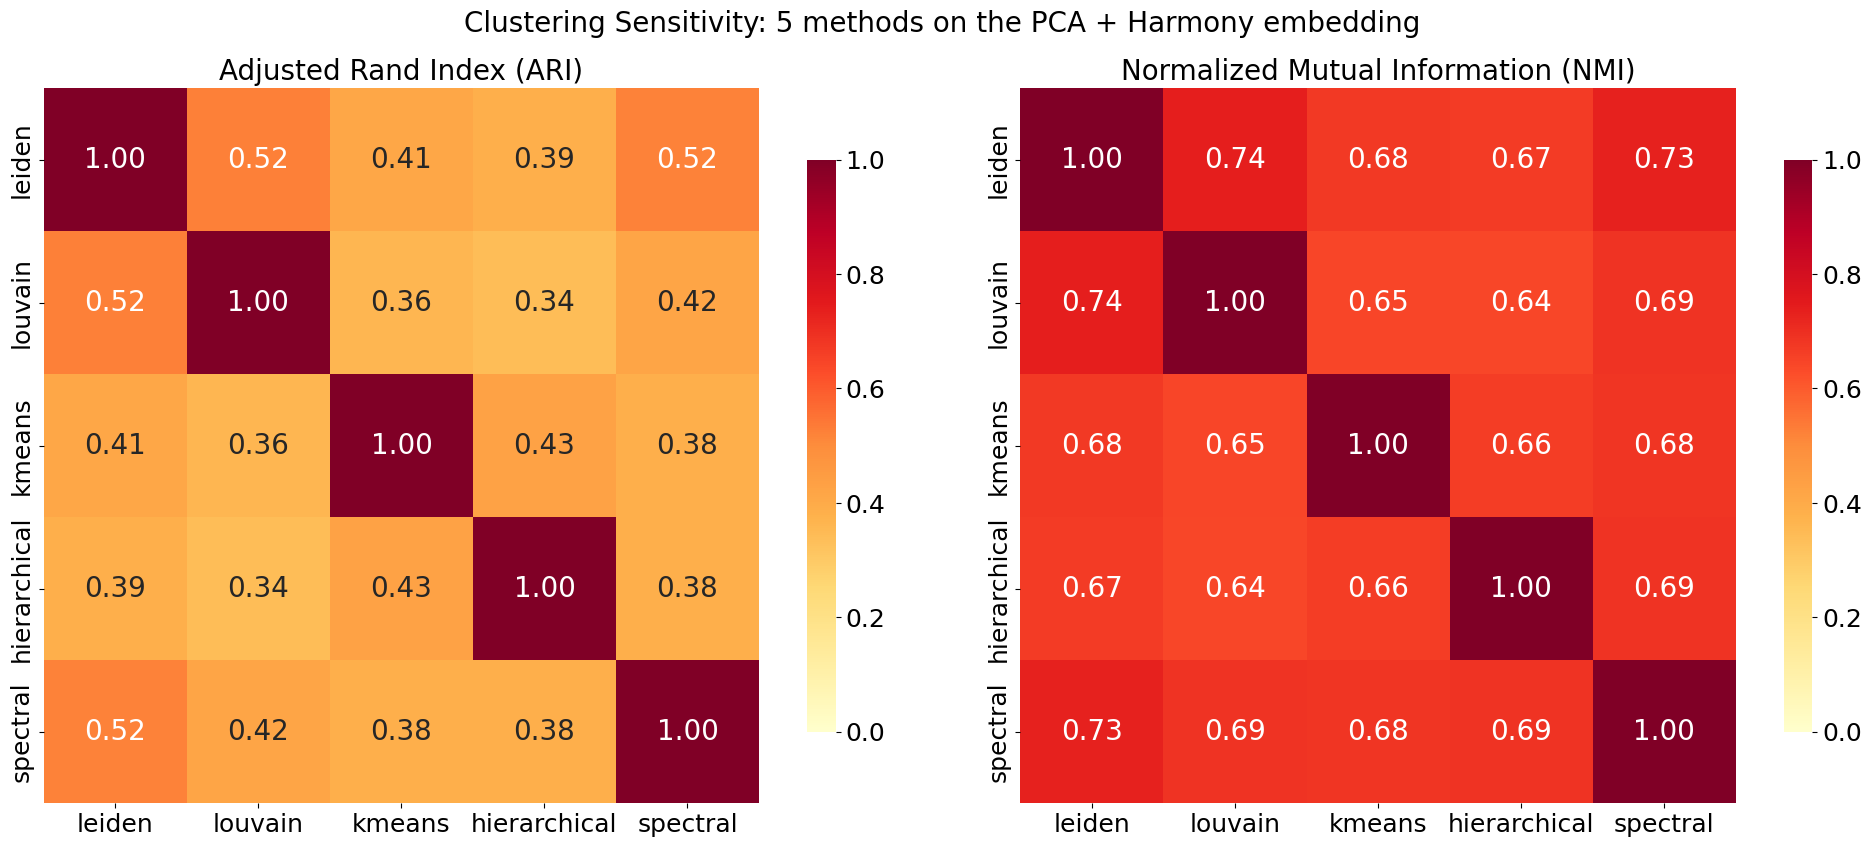

In [46]:
# ARI / NMI heatmap (matches Random_Clustering_reproducibility layout).
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

sns.heatmap(ari_df, annot=True, fmt='.2f', cmap='YlOrRd', vmin=0, vmax=1,
            square=True, ax=axes[0], cbar_kws={'shrink': 0.8},
            annot_kws={'size': 20})
axes[0].set_title('Adjusted Rand Index (ARI)', fontsize=20)
axes[0].tick_params(axis='both', labelsize=18)
axes[0].collections[0].colorbar.ax.tick_params(labelsize=18)

sns.heatmap(nmi_df, annot=True, fmt='.2f', cmap='YlOrRd', vmin=0, vmax=1,
            square=True, ax=axes[1], cbar_kws={'shrink': 0.8},
            annot_kws={'size': 20})
axes[1].set_title('Normalized Mutual Information (NMI)', fontsize=20)
axes[1].tick_params(axis='both', labelsize=18)
axes[1].collections[0].colorbar.ax.tick_params(labelsize=18)

plt.suptitle('Clustering Sensitivity: 5 methods on the PCA + Harmony embedding',
             fontsize=20, y=1.02)
plt.tight_layout()
plt.savefig('clustering_sensitivity_heatmap.png', dpi=300, bbox_inches='tight')
plt.savefig('clustering_sensitivity_heatmap.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [47]:
# Summary statistics (off-diagonal pairs of the 5-method PCA-pipeline matrix).
ari_vals = ari_matrix[np.triu_indices(n, k=1)]
nmi_vals = nmi_matrix[np.triu_indices(n, k=1)]

print(f"All pairwise comparisons ({len(ari_vals)} pairs, PCA pipeline only):")
print(f"  ARI: mean={ari_vals.mean():.4f}, min={ari_vals.min():.4f}, "
      f"max={ari_vals.max():.4f}, std={ari_vals.std():.4f}")
print(f"  NMI: mean={nmi_vals.mean():.4f}, min={nmi_vals.min():.4f}, "
      f"max={nmi_vals.max():.4f}, std={nmi_vals.std():.4f}")

# Dimensionality-reduction comparison (PCA Leiden vs no-PCA Leiden) is a
# separate one-off computation, not part of the pairwise matrix above.
leiden_pca   = _aligned(adata_pca,   'leiden').values
leiden_nopca = _aligned(adata_nopca, 'leiden').values
mask_dimred  = pd.notna(leiden_pca) & pd.notna(leiden_nopca)
ari_dimred = adjusted_rand_score(leiden_pca[mask_dimred], leiden_nopca[mask_dimred])
nmi_dimred = normalized_mutual_info_score(leiden_pca[mask_dimred], leiden_nopca[mask_dimred])
print(f"\nPCA Leiden vs no-PCA Leiden (dimensionality-reduction sensitivity):")
print(f"  ARI = {ari_dimred:.4f}")
print(f"  NMI = {nmi_dimred:.4f}")

ari_df.to_csv('sensitivity_ARI_matrix.csv')
nmi_df.to_csv('sensitivity_NMI_matrix.csv')
print("\nSaved sensitivity_ARI_matrix.csv, sensitivity_NMI_matrix.csv")

All pairwise comparisons (10 pairs, PCA pipeline only):
  ARI: mean=0.4162, min=0.3410, max=0.5248, std=0.0589
  NMI: mean=0.6832, min=0.6431, max=0.7384, std=0.0307

PCA Leiden vs no-PCA Leiden (dimensionality-reduction sensitivity):
  ARI = 0.4417
  NMI = 0.6370

Saved sensitivity_ARI_matrix.csv, sensitivity_NMI_matrix.csv


---
# Part 4: 2nd-brain plotting AnnData

Build a 2nd-brain AnnData restricted to cells present in both the PCA and
no-PCA pipelines, and attach the cluster labels from every method, plus
the UMAP/spatial coordinates used by the section-6 composite figure.

In [48]:
# === Section-4 configuration (mirrors Random_Clustering_reproducibility) ===
OUTPUT_DIR = 'output/'
OUTPUT_PREFIX = ''            # e.g. 'dimred_' to isolate outputs

def _outpath(name):
    return os.path.join(OUTPUT_DIR, f"{OUTPUT_PREFIX}{name}")

# Composite-figure inputs
COMPOSITE_EXAMPLE_KEYS = ['leiden', 'louvain', 'kmeans',
                          'hierarchical', 'spectral', 'leiden_noPCA']
COMPOSITE_MIN_CELLS = 500
SPATIAL_ROTATION_DEG = -137

# Styling
DOT_SIZE = 0.15
TITLE_FS = 18
AXIS_LABEL_FS = 14
TICK_FS = 12
CLUSTER_LABEL_FS = 8

print(f"Output directory: {os.path.abspath(OUTPUT_DIR)!r}")
print(f"Output prefix:    {OUTPUT_PREFIX!r}")

Output directory: 'h:\\53Ab_wholebrain7.17.25\\3rd_wholebrain_output\\Step5\\final_codes\\vii_Validation_robustness_tests\\output'
Output prefix:    ''


In [50]:
# Build the 2nd-brain plotting AnnData and attach every clustering label.
# The analysis brain is dataset='2nd_brain'; the Harmony / Leiden labels
# for those cells live in adata_pca / adata_nopca.
import warnings
warnings.filterwarnings("ignore")

ANALYSIS_BRAIN_KEY = '2nd_brain'

# Mask + obs_names of analysis-brain cells in each pipeline.
mask_pca   = (adata_pca.obs['dataset']   == ANALYSIS_BRAIN_KEY).values
mask_nopca = (adata_nopca.obs['dataset'] == ANALYSIS_BRAIN_KEY).values
obs_names_pca   = adata_pca.obs_names[mask_pca].astype(str)
obs_names_nopca = adata_nopca.obs_names[mask_nopca].astype(str)

# Cells common to both pipelines (protein PCA, protein no-PCA).
common_cells = pd.Index(obs_names_pca).intersection(pd.Index(obs_names_nopca))
if len(common_cells) == 0:
    raise RuntimeError(
        f"No overlap between {ANALYSIS_BRAIN_KEY} cells (PCA) and "
        f"{ANALYSIS_BRAIN_KEY} cells (no PCA)."
    )

# Labels-only AnnData (zero features) -- just carries obsm/obs for plotting.
adata_plot = ad.AnnData(
    X=np.empty((len(common_cells), 0), dtype=np.float32),
    obs=pd.DataFrame(index=common_cells),
)

# Position arrays for slicing obsm of adata_pca / adata_nopca.
pca_positions   = adata_pca.obs_names.astype(str).get_indexer(common_cells)
nopca_positions = adata_nopca.obs_names.astype(str).get_indexer(common_cells)

# Spatial coords from adata_pca (same cells, same spatial), UMAP from PCA pipeline.
adata_plot.obsm['spatial'] = adata_pca.obsm['spatial'][pca_positions]
adata_plot.obsm['X_umap']  = adata_pca.obsm['X_umap'][pca_positions]

# Cluster labels: 5 methods on PCA Harmony + no-PCA Leiden.
# Drop any cells whose label is missing in either pipeline (NaN -> string 'nan'
# after astype(str), so explicitly filter those out before building categoricals).
for key in ['leiden', 'louvain', 'kmeans', 'hierarchical', 'spectral']:
    lab = np.asarray(adata_pca.obs[key].astype(str).values)[pca_positions]
    lab[lab == 'nan'] = np.nan
    adata_plot.obs[key] = pd.Categorical(lab)

lab_nopca = np.asarray(adata_nopca.obs['leiden'].astype(str).values)[nopca_positions]
lab_nopca[lab_nopca == 'nan'] = np.nan
adata_plot.obs['leiden_noPCA'] = pd.Categorical(lab_nopca)

label_keys = ['leiden', 'louvain', 'kmeans', 'hierarchical', 'spectral', 'leiden_noPCA']

print(f"adata_plot: {adata_plot.n_obs} cells")
print(f"Label sets: {label_keys}")

adata_plot: 194890 cells
Label sets: ['leiden', 'louvain', 'kmeans', 'hierarchical', 'spectral', 'leiden_noPCA']


---
# Part 5: 2-column composite figure (UMAP / spatial)

One row per clustering method.  Cluster colors are synchronized between the
UMAP (col 1) and spatial (col 2) panels within each row.

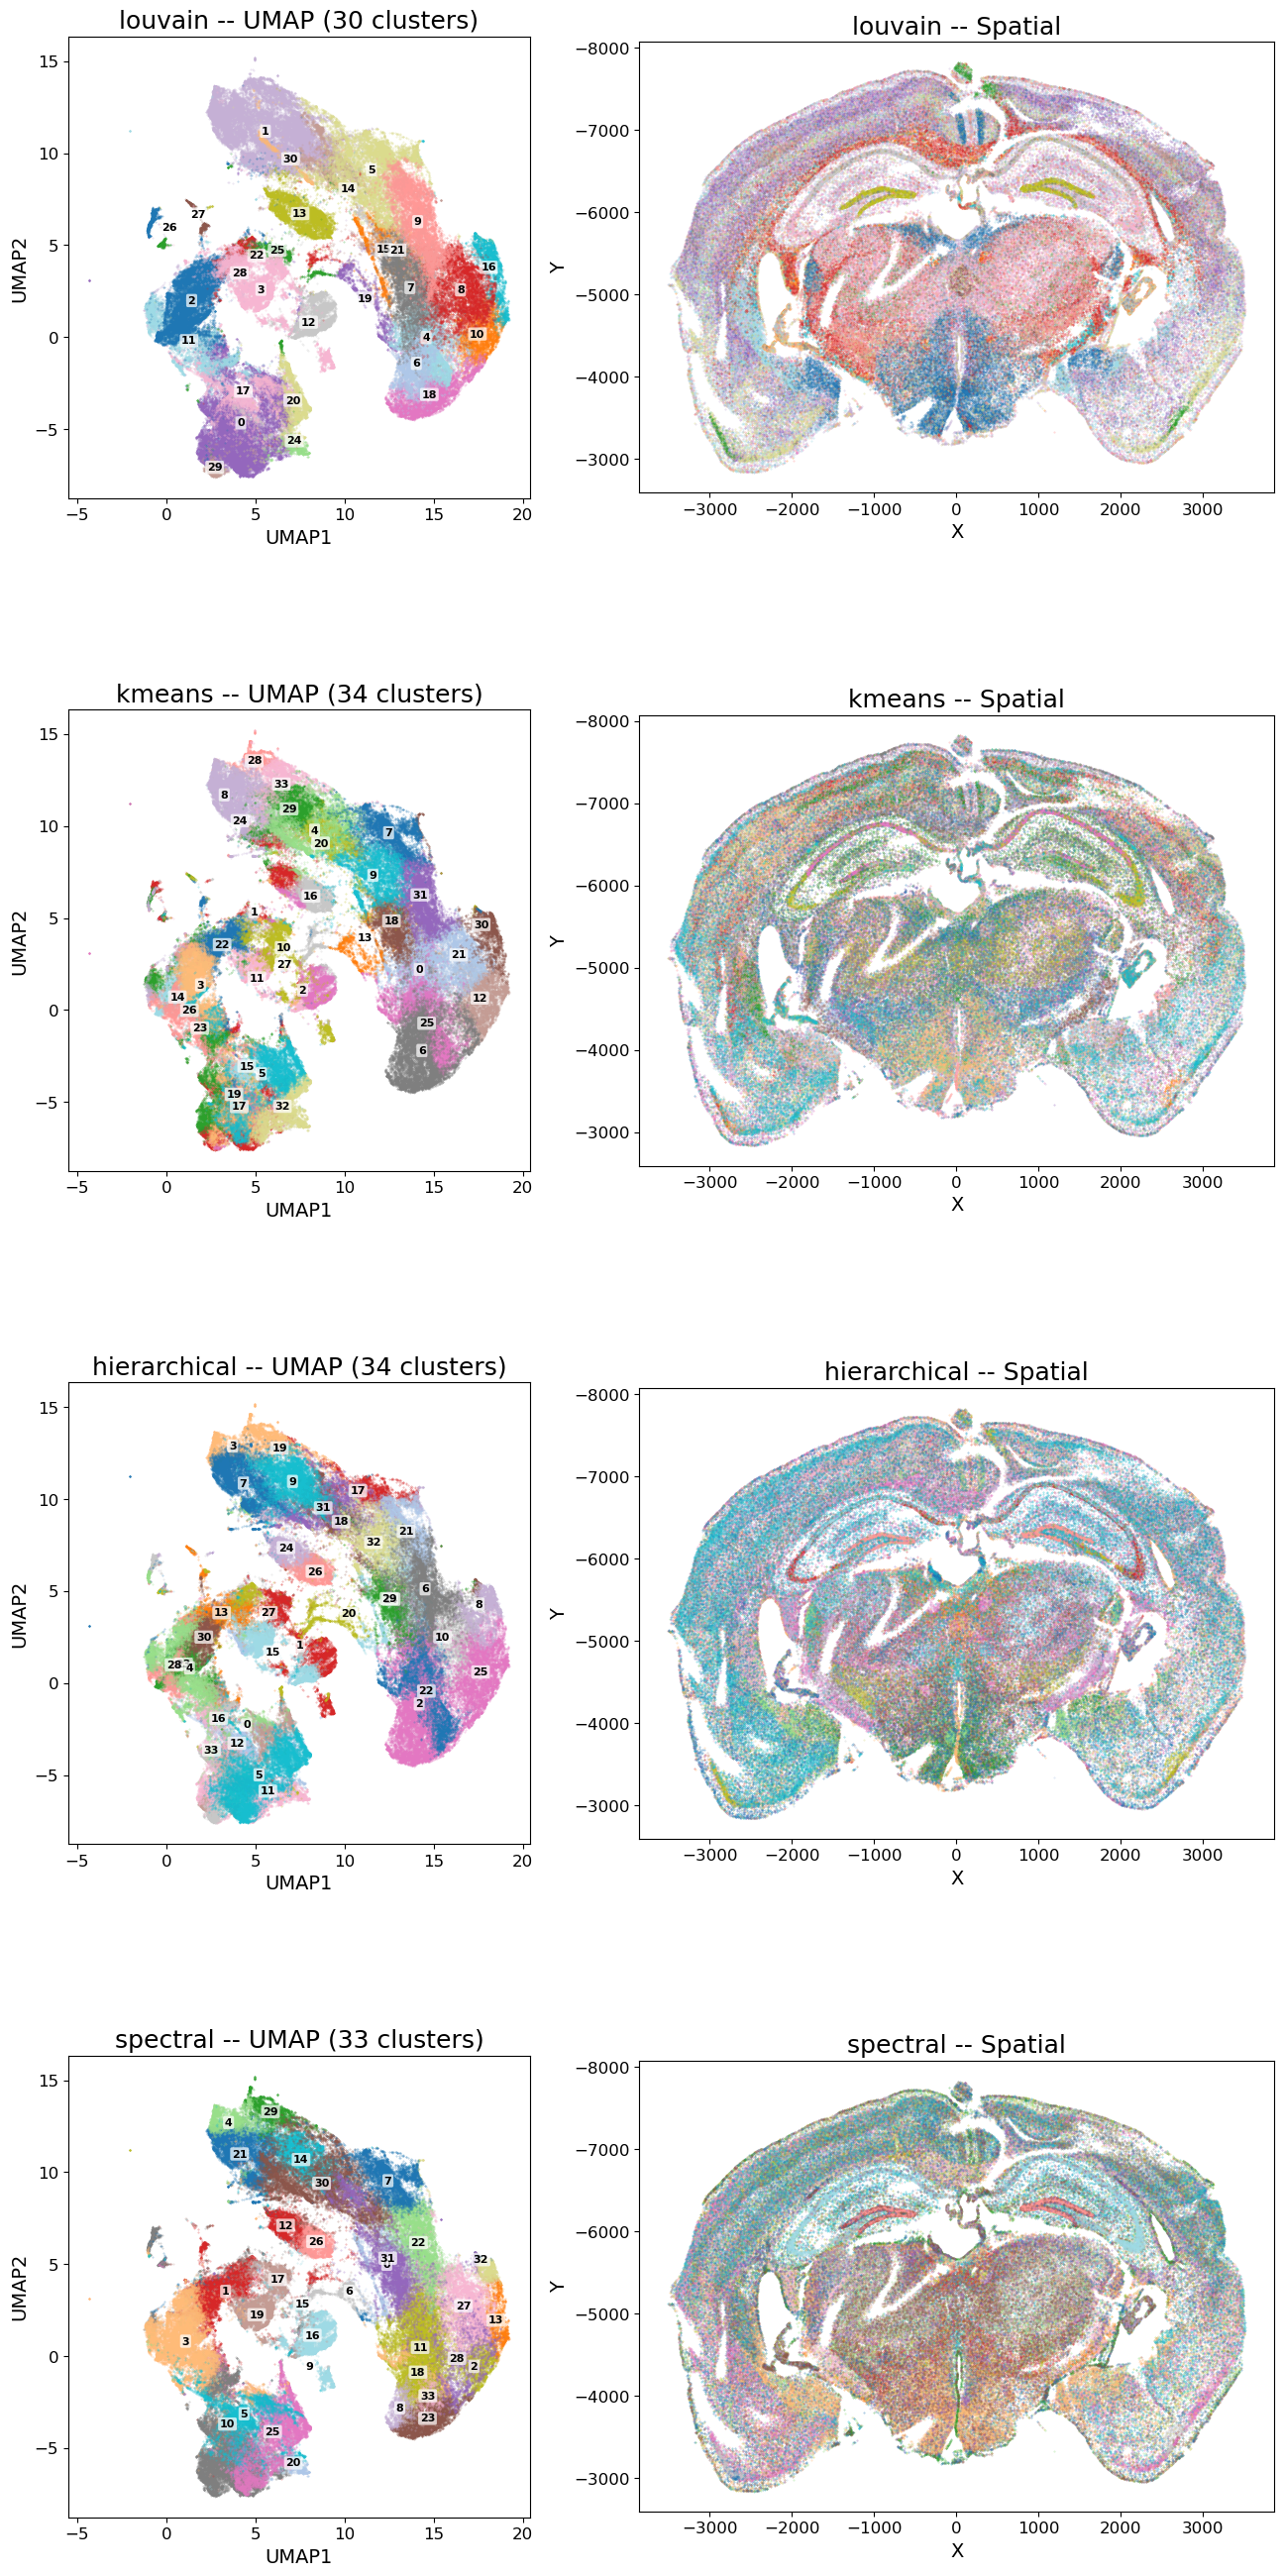

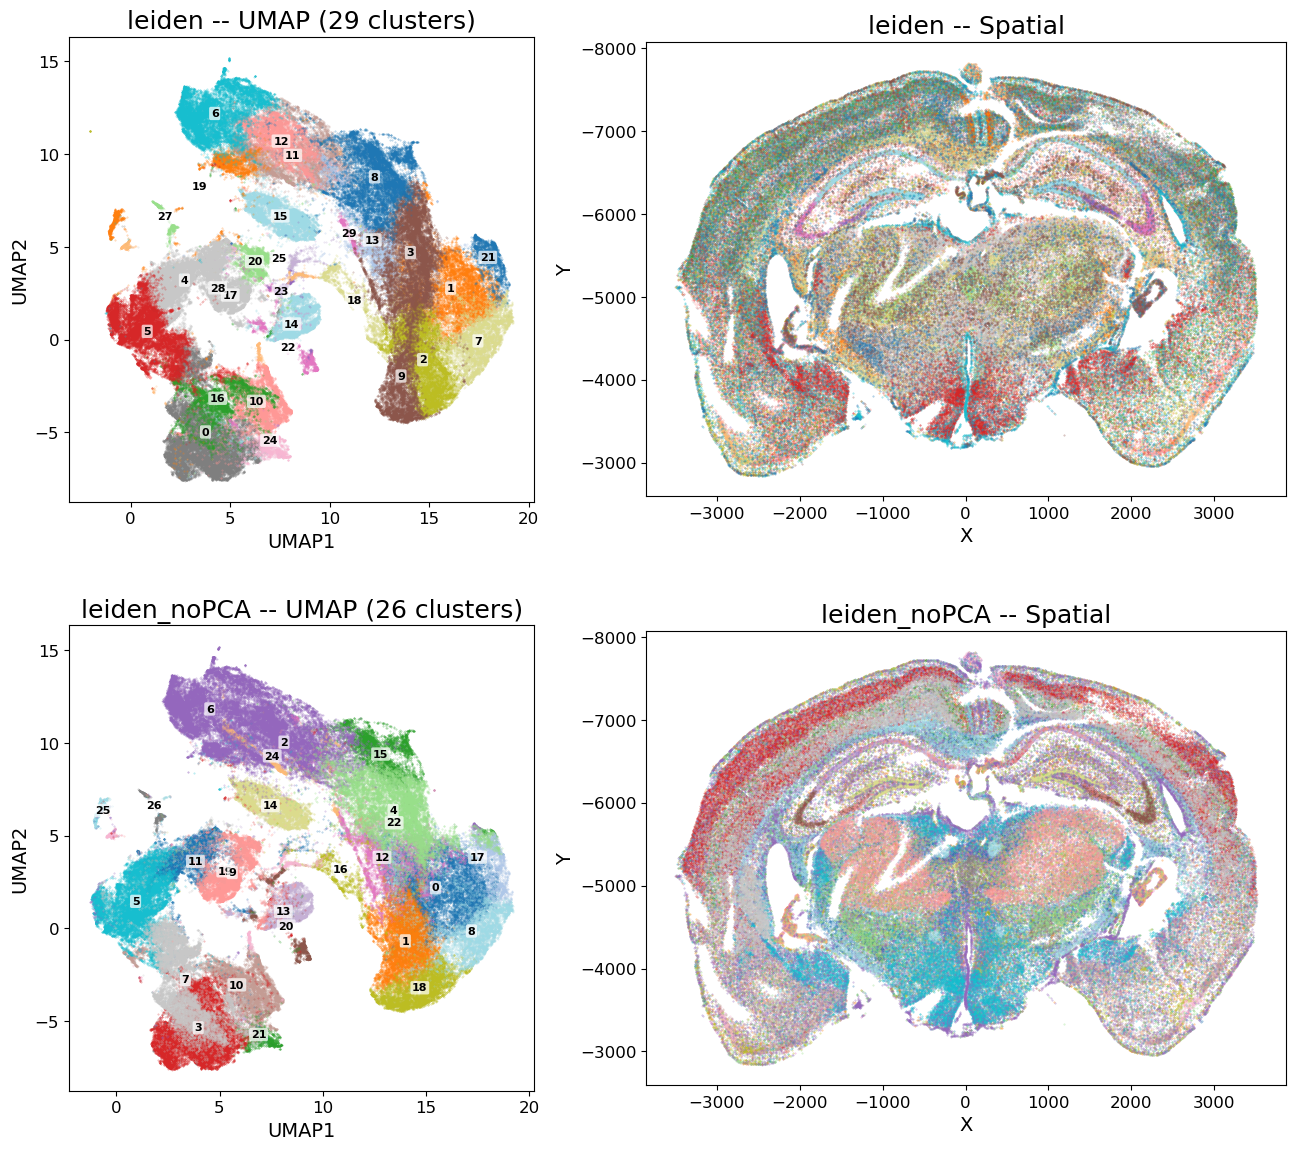

In [54]:
# 2-column composite figure (UMAP / spatial; matches
# Random_Clustering_reproducibility.ipynb layout minus the RNA z-score heatmap column).
# Wrapped in a function so we can render two versions: (1) the four non-Leiden
# clustering methods, (2) PCA Leiden vs no-PCA Leiden, saved as separate files.

# Per-method palette seeds. Different seeds produce visually distinct tab20
# permutations even when two methods share the same cluster count, so louvain
# and the no-PCA Leiden don't look identical to the PCA Leiden row.
PALETTE_SEEDS = {
    'leiden':       0,
    'louvain':      7,
    'kmeans':       0,
    'hierarchical': 0,
    'spectral':     0,
    'leiden_noPCA': 13,
}


def _shuffled_palette(n, seed=0):
    base = plt.cm.get_cmap("tab20", max(n, 20))
    rng = np.random.default_rng(seed)
    perm = rng.permutation(max(n, 20))
    return [base(int(p)) for p in perm[:n]]


# Rotate spatial coords once (used by every composite render).
_theta = np.radians(SPATIAL_ROTATION_DEG)
_R = np.array([[np.cos(_theta), -np.sin(_theta)],
               [np.sin(_theta),  np.cos(_theta)]])
adata_plot.obsm['spatial_rotated'] = adata_plot.obsm['spatial'] @ _R.T


def render_composite(keys, out_basename):
    """Render the 2-column composite (UMAP / spatial) for a given ordered
    list of clustering keys and save it to disk."""
    n_rows = len(keys)

    fig, axes = plt.subplots(
        n_rows, 2,
        figsize=(13.06, 8 * n_rows),
        gridspec_kw={'width_ratios': [5.5, 7.56]},  # spatial keeps its size; UMAP cell is narrower
    )
    if n_rows == 1:
        axes = axes.reshape(1, 2)

    for r, key in enumerate(keys):
        labels_cat = adata_plot.obs[key].astype('category')
        cats_all = labels_cat.cat.categories
        counts = labels_cat.value_counts()
        keep = [c for c in cats_all if int(counts.get(c, 0)) >= COMPOSITE_MIN_CELLS]
        cats = pd.Index(keep)
        n_clust = len(cats)

        palette = _shuffled_palette(n_clust, seed=PALETTE_SEEDS.get(key, 0))
        cluster_colors = {c: palette[i] for i, c in enumerate(cats)}

        # Col 1 -- UMAP
        ax = axes[r, 0]
        ax.set_box_aspect(1)  # keep UMAP square, sized down to the narrower cell width
        umap_xy = adata_plot.obsm['X_umap']
        for cat in cats:
            m = (labels_cat == cat).values
            ax.scatter(umap_xy[m, 0], umap_xy[m, 1], s=DOT_SIZE,
                       c=[cluster_colors[cat]], alpha=0.4, rasterized=True)
            cx, cy = umap_xy[m, 0].mean(), umap_xy[m, 1].mean()
            ax.text(cx, cy, str(cat), fontsize=CLUSTER_LABEL_FS, fontweight='bold',
                    ha='center', va='center',
                    bbox=dict(boxstyle='round,pad=0.15', fc='white', alpha=0.7, lw=0))
        ax.set_title(f'{key} -- UMAP ({n_clust} clusters)',
                      fontsize=TITLE_FS)
        ax.set_xlabel('UMAP1', fontsize=AXIS_LABEL_FS)
        ax.set_ylabel('UMAP2', fontsize=AXIS_LABEL_FS)
        ax.tick_params(axis='both', labelsize=TICK_FS)

        # Col 2 -- Spatial (rotated)
        ax = axes[r, 1]
        xy = adata_plot.obsm['spatial_rotated']
        for cat in cats:
            m = (labels_cat == cat).values
            ax.scatter(xy[m, 0], xy[m, 1], s=DOT_SIZE,
                       c=[cluster_colors[cat]], alpha=0.5, rasterized=True)
        ax.set_title(f'{key} -- Spatial',
                      fontsize=TITLE_FS)
        ax.set_xlabel('X', fontsize=AXIS_LABEL_FS)
        ax.set_ylabel('Y', fontsize=AXIS_LABEL_FS)
        ax.tick_params(axis='both', labelsize=TICK_FS)
        ax.set_aspect('equal'); ax.invert_yaxis()

    plt.tight_layout()
    plt.subplots_adjust(hspace=-0.4)
    plt.savefig(_outpath(f'{out_basename}.pdf'), dpi=200, bbox_inches='tight')
    plt.savefig(_outpath(f'{out_basename}.png'), dpi=200, bbox_inches='tight')
    plt.show()


# Clustering-method sensitivity figure: the four non-Leiden methods.
# (Leiden + no-PCA Leiden go into a separate figure below.)
render_composite(
    ['louvain', 'kmeans', 'hierarchical', 'spectral'],
    'clustering_composite',
)

# Dimensionality-reduction sensitivity figure: PCA Leiden vs no-PCA Leiden.
render_composite(
    ['leiden', 'leiden_noPCA'],
    'clustering_composite_leiden_pca_vs_nopca',
)